In [1]:
import cv2
import numpy as np
import os
from glob import glob
import shutil
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
def dark_spotlight_pro(img):
    """Dark Spotlight PRO: Gamma Correction + Median Blur + LAB CLAHE + Unsharp Masking"""
    # 1. Gamma Correction (lifts shadows / balances brightness)
    inv_gamma = 1.0 / 0.7
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype("uint8")
    gamma_res = cv2.LUT(img, table)
    
    # 2. Median Blur (reduces grainy underwater snow)
    blurred = cv2.medianBlur(gamma_res, 3)
    
    # 3. CLAHE in LAB space (boosts local contrast without oversaturation)
    lab = cv2.cvtColor(blurred, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    merged = cv2.merge((cl, a, b))
    clahe_res = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)
    
    # 4. Unsharp Masking (enhances edges and fine details)
    gaussian = cv2.GaussianBlur(clahe_res, (0, 0), 1.0)
    return cv2.addWeighted(clahe_res, 1.0 + 1.2, gaussian, -1.2, 0)

print("Enhancement function ready!")

Enhancement function ready!


In [3]:
# Grab one sample image from your train folder
sample_images = glob("dataset/images/train/*.*")
if sample_images:
    sample_path = sample_images[0]
    original = cv2.imread(sample_path)
    enhanced = dark_spotlight_pro(original)

    # Convert BGR to RGB for correct matplotlib display
    orig_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    enh_rgb = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(orig_rgb)
    plt.title("Original Underwater Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(enh_rgb)
    plt.title("Enhanced (Dark Spotlight PRO)")
    plt.axis('off')
    plt.show()
else:
    print("No images found in dataset/images/train/ yet.")

No images found in dataset/images/train/ yet.


In [4]:
input_base = "dataset/images"
output_base = "dataset_enhanced/images"

for split in ['train', 'val']:
    in_dir = os.path.join(input_base, split)
    out_dir = os.path.join(output_base, split)
    os.makedirs(out_dir, exist_ok=True)

    print(f"Processing {split} images...")
    for img_path in glob(os.path.join(in_dir, "*.*")):
        filename = os.path.basename(img_path)
        img = cv2.imread(img_path)
        if img is None:
            continue

        enhanced_img = dark_spotlight_pro(img)
        cv2.imwrite(os.path.join(out_dir, filename), enhanced_img)

# Copy labels over to dataset_enhanced for YOLO training compatibility
if os.path.exists("dataset/labels"):
    if os.path.exists("dataset_enhanced/labels"):
        shutil.rmtree("dataset_enhanced/labels")
    shutil.copytree("dataset/labels", "dataset_enhanced/labels")

print("All images successfully enhanced and saved to dataset_enhanced/!")

Processing train images...
Processing val images...
All images successfully enhanced and saved to dataset_enhanced/!


In [7]:
import os
import shutil

# Use '../dataset/labels' because the notebook is inside the 'notebooks' subfolder
src_labels = "../dataset/labels"
dst_labels = "../dataset_enhanced/labels"

if os.path.exists(src_labels):
    print("Found base dataset/labels folder!")
    if os.path.exists(dst_labels):
        shutil.rmtree(dst_labels)
    shutil.copytree(src_labels, dst_labels)
    print("Success! Labels copied to dataset_enhanced/labels.")
else:
    print("Error: dataset/labels was still not found at:", os.path.abspath(src_labels))

Found base dataset/labels folder!
Success! Labels copied to dataset_enhanced/labels.


In [8]:
import cv2
import numpy as np
import os
from glob import glob

def dark_spotlight_pro(img):
    """Dark Spotlight PRO: Gamma + Median Blur + LAB CLAHE + Unsharp Masking"""
    inv_gamma = 1.0 / 0.7
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype("uint8")
    gamma_res = cv2.LUT(img, table)
    blurred = cv2.medianBlur(gamma_res, 3)
    
    lab = cv2.cvtColor(blurred, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    merged = cv2.merge((cl, a, b))
    clahe_res = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)
    
    gaussian = cv2.GaussianBlur(clahe_res, (0, 0), 1.0)
    return cv2.addWeighted(clahe_res, 1.0 + 1.2, gaussian, -1.2, 0)

# Process images using paths relative from inside the 'notebooks' folder
input_base = "../dataset/images"
output_base = "../dataset_enhanced/images"

for split in ['train', 'val']:
    in_dir = os.path.join(input_base, split)
    out_dir = os.path.join(output_base, split)
    os.makedirs(out_dir, exist_ok=True)

    print(f"Processing and enhancing {split} images...")
    img_paths = glob(os.path.join(in_dir, "*.*"))
    for img_path in img_paths:
        filename = os.path.basename(img_path)
        img = cv2.imread(img_path)
        if img is None:
            continue

        enhanced_img = dark_spotlight_pro(img)
        cv2.imwrite(os.path.join(out_dir, filename), enhanced_img)

print("All training and validation images successfully enhanced and saved!")

Processing and enhancing train images...
Processing and enhancing val images...
All training and validation images successfully enhanced and saved!


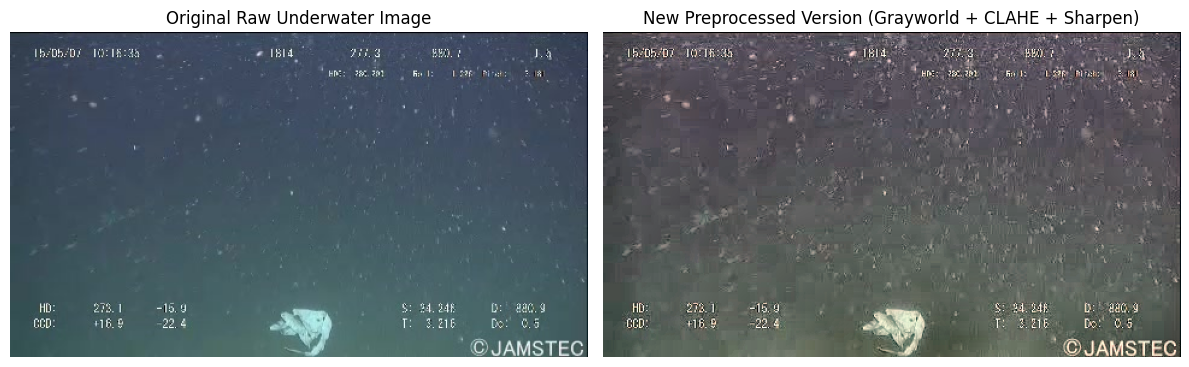

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

def advanced_multi_space_pipeline(img):
    """
    Multi-Space Pipeline: 
    1. Grayworld Color Balance (removes green/blue cast)
    2. LAB CLAHE (boosts local contrast)
    3. Unsharp Masking (sharpens object boundaries)
    """
    # Step 1: Grayworld Color Balance
    result = img.astype(np.float32)
    average_b = np.mean(result[:, :, 0])
    average_g = np.mean(result[:, :, 1])
    average_r = np.mean(result[:, :, 2])
    average_gray = (average_b + average_g + average_r) / 3.0
    
    result[:, :, 0] *= (average_gray / average_b)
    result[:, :, 1] *= (average_gray / average_g)
    result[:, :, 2] *= (average_gray / average_r)
    gw_img = np.clip(result, 0, 255).astype(np.uint8)
    
    # Step 2: CLAHE in LAB space
    lab = cv2.cvtColor(gw_img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    merged = cv2.merge((cl, a, b))
    clahe_res = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)
    
    # Step 3: Unsharp Masking
    gaussian = cv2.GaussianBlur(clahe_res, (0, 0), 1.0)
    final_res = cv2.addWeighted(clahe_res, 1.3, gaussian, -0.3, 0)
    
    return final_res

# Grab a sample original image to test
sample_images = glob("../dataset/images/train/*.*")
if sample_images:
    sample_path = sample_images[0]
    original = cv2.imread(sample_path)
    
    # Apply new preprocessing pipeline
    enhanced_version = advanced_multi_space_pipeline(original)

    # Convert BGR to RGB for matplotlib display
    orig_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    enh_rgb = cv2.cvtColor(enhanced_version, cv2.COLOR_BGR2RGB)

    # Plot Side-by-Side Comparison
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(orig_rgb)
    plt.title("Original Raw Underwater Image", fontsize=12)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(enh_rgb)
    plt.title("New Preprocessed Version (Grayworld + CLAHE + Sharpen)", fontsize=12)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Sample images not found.")

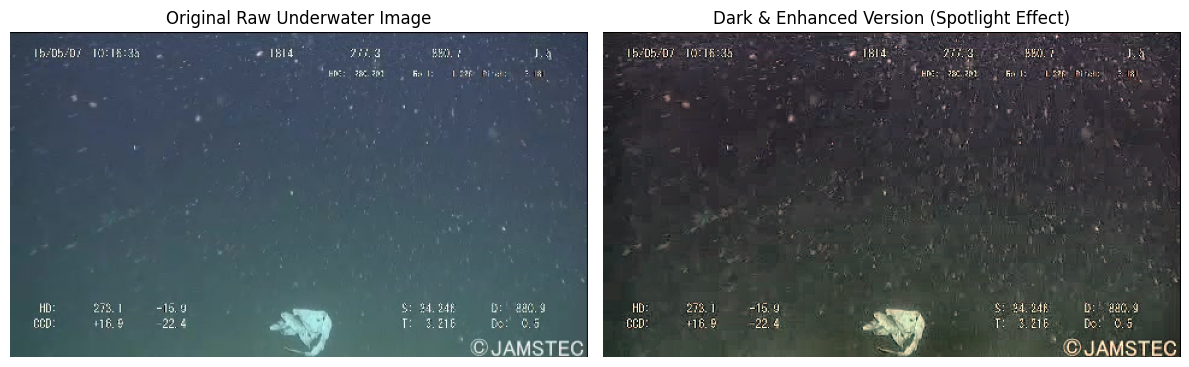

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

def dark_multi_space_pipeline(img):
    """
    Dark Multi-Space Pipeline:
    1. Grayworld Color Balance (removes green/blue cast)
    2. Heavy Gamma / Darkening (crushes foggy midtones into deep black)
    3. LAB CLAHE (boosts local contrast)
    4. Unsharp Masking (sharpens object boundaries)
    """
    # Step 1: Grayworld Color Balance
    result = img.astype(np.float32)
    average_b = np.mean(result[:, :, 0])
    average_g = np.mean(result[:, :, 1])
    average_r = np.mean(result[:, :, 2])
    average_gray = (average_b + average_g + average_r) / 3.0
    
    result[:, :, 0] *= (average_gray / average_b)
    result[:, :, 1] *= (average_gray / average_g)
    result[:, :, 2] *= (average_gray / average_r)
    gw_img = np.clip(result, 0, 255).astype(np.uint8)
    
    # Step 2: Heavy Gamma / Darkening (Gamma < 1.0 darkens midtones/fog)
    gamma = 0.65  # Adjust this value: lower = darker background, higher = brighter
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype("uint8")
    dark_img = cv2.LUT(gw_img, table)
    
    # Step 3: CLAHE in LAB space for local pop
    lab = cv2.cvtColor(dark_img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    merged = cv2.merge((cl, a, b))
    clahe_res = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)
    
    # Step 4: Unsharp Masking
    gaussian = cv2.GaussianBlur(clahe_res, (0, 0), 1.0)
    final_res = cv2.addWeighted(clahe_res, 1.3, gaussian, -0.3, 0)
    
    return final_res

# Grab a sample original image to test
sample_images = glob("../dataset/images/train/*.*")
if sample_images:
    sample_path = sample_images[0]
    original = cv2.imread(sample_path)
    
    # Apply dark preprocessing pipeline
    enhanced_version = dark_multi_space_pipeline(original)

    # Convert BGR to RGB for matplotlib display
    orig_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    enh_rgb = cv2.cvtColor(enhanced_version, cv2.COLOR_BGR2RGB)

    # Plot Side-by-Side Comparison
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(orig_rgb)
    plt.title("Original Raw Underwater Image", fontsize=12)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(enh_rgb)
    plt.title("Dark & Enhanced Version (Spotlight Effect)", fontsize=12)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Sample images not found.")

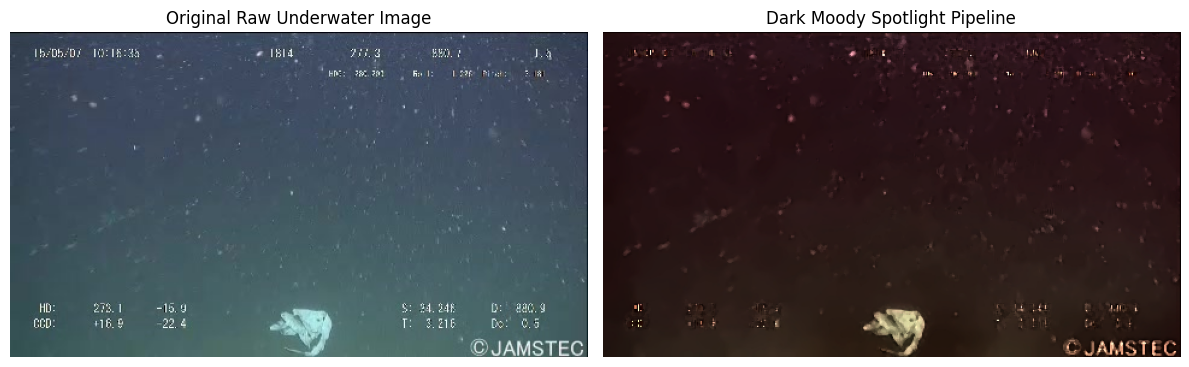

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

def dark_moody_underwater_pipeline(img):
    """
    Dark Moody Spotlight Pipeline:
    1. Grayworld Color Balance (remove blue/green cast)
    2. LAB CLAHE (local contrast)
    3. Strong Gamma Correction (makes background dark and deep)
    4. Red Channel Boost (restores natural tones)
    5. NLM & Median Denoising (cleans up snow)
    6. Unsharp Masking (crisp object borders without washing out)
    """
    # 1. Grayworld Color Balance
    result = img.astype(np.float32)
    avg_b = np.mean(result[:, :, 0])
    avg_g = np.mean(result[:, :, 1])
    avg_r = np.mean(result[:, :, 2])
    avg_gray = (avg_b + avg_g + avg_r) / 3.0
    result[:, :, 0] *= (avg_gray / avg_b)
    result[:, :, 1] *= (avg_gray / avg_g)
    result[:, :, 2] *= (avg_gray / avg_r)
    gw = np.clip(result, 0, 255).astype(np.uint8)
    
    # 2. LAB CLAHE
    lab = cv2.cvtColor(gw, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    clahe_res = cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2BGR)
    
    # 3. Strong Gamma Correction (Lower gamma = darker background/shadows)
    gamma = 0.45  # Made significantly darker for a deep-sea spotlight look
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype("uint8")
    gamma_res = cv2.LUT(clahe_res, table)
    
    # 4. Red Channel Boost
    b_ch, g_ch, r_ch = cv2.split(gamma_res)
    r_ch = cv2.add(r_ch, 20)
    red_boosted = cv2.merge((b_ch, g_ch, np.clip(r_ch, 0, 255).astype(np.uint8)))
    
    # 5. Denoising (NLM + Median Blur)
    denoised = cv2.fastNlMeansDenoisingColored(red_boosted, None, h=5, templateWindowSize=7, searchWindowSize=21)
    denoised = cv2.medianBlur(denoised, 3)
    
    # 6. Final Sharpening (Unsharp Mask instead of Retinex to avoid white washing)
    gaussian = cv2.GaussianBlur(denoised, (0, 0), 1.5)
    final_res = cv2.addWeighted(denoised, 1.5, gaussian, -0.5, 0)
    
    return final_res

# Test on a sample image and show comparison
sample_images = glob("../dataset/images/train/*.*")
if sample_images:
    sample_path = sample_images[0]
    original = cv2.imread(sample_path)
    
    enhanced_version = dark_moody_underwater_pipeline(original)

    orig_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    enh_rgb = cv2.cvtColor(enhanced_version, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(orig_rgb)
    plt.title("Original Raw Underwater Image", fontsize=12)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(enh_rgb)
    plt.title("Dark Moody Spotlight Pipeline", fontsize=12)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Sample images not found.")

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

def refined_spotlight_pipeline(img):
    """
    Refined Moody Spotlight Pipeline:
    1. Balanced Grayworld Color Balance
    2. LAB CLAHE for local object contrast
    3. Balanced Gamma Correction (keeps background deep without crushing details)
    4. Controlled Red Channel Boost (prevents overly red/brown hue)
    5. NLM & Median Denoising (removes floating snow)
    6. Crisp Unsharp Masking
    """
    # 1. Grayworld Color Balance
    result = img.astype(np.float32)
    avg_b = np.mean(result[:, :, 0])
    avg_g = np.mean(result[:, :, 1])
    avg_r = np.mean(result[:, :, 2])
    avg_gray = (avg_b + avg_g + avg_r) / 3.0
    result[:, :, 0] *= (avg_gray / avg_b)
    result[:, :, 1] *= (avg_gray / avg_g)
    result[:, :, 2] *= (avg_gray / avg_r)
    gw = np.clip(result, 0, 255).astype(np.uint8)
    
    # 2. LAB CLAHE (slightly higher clipLimit to make the object pop)
    lab = cv2.cvtColor(gw, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    clahe_res = cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2BGR)
    
    # 3. Gamma Correction (Gamma = 0.55 for a balanced dark background)
    gamma = 0.55
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype("uint8")
    gamma_res = cv2.LUT(clahe_res, table)
    
    # 4. Controlled Red Channel Boost (mild adjustment to avoid strong red tint)
    b_ch, g_ch, r_ch = cv2.split(gamma_res)
    r_ch = cv2.add(r_ch, 8) # Reduced red boost for natural tone balance
    balanced_color = cv2.merge((b_ch, g_ch, np.clip(r_ch, 0, 255).astype(np.uint8)))
    
    # 5. Denoising (NLM + Median Blur)
    denoised = cv2.fastNlMeansDenoisingColored(balanced_color, None, h=4, templateWindowSize=7, searchWindowSize=21)
    denoised = cv2.medianBlur(denoised, 3)
    
    # 6. Unsharp Masking for crystal clear edges
    gaussian = cv2.GaussianBlur(denoised, (0, 0), 1.0)
    final_res = cv2.addWeighted(denoised, 1.4, gaussian, -0.4, 0)
    
    return final_res

# Test on a sample image and show comparison
sample_images = glob("../dataset/images/train/*.*")
if sample_images:
    sample_path = sample_images[0]
    original = cv2.imread(sample_path)
    
    enhanced_version = refined_spotlight_pipeline(original)

    orig_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    enh_rgb = cv2.cvtColor(enhanced_version, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(orig_rgb)
    plt.title("Original Raw Underwater Image", fontsize=12)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(enh_rgb)
    plt.title("Refined Moody Spotlight Pipeline", fontsize=12)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Sample images not found.")